# Matching pipeline

The comparison method is used in statistical analysis to eliminate distortions caused by differences in the basic characteristics of the studied groups. Simply put, matching helps to make sure that the results of the experiment are really caused by the studied effect, and not by external factors.

Matching is most often performed in cases where the use of a standard AB test is impossible.

In [1]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hypex import Matching
from hypex.dataset import (
    Dataset,
    FeatureRole,
    GroupingRole,
    InfoRole,
    TargetRole,
    TreatmentRole,
)
from hypex.utils import create_test_data

/Users/danilsamsutdinov/HypEx/.venv/lib/python3.11/site-packages/pyspark/pandas/__init__.py:50: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


# Create synthetic data

In [2]:
df = create_test_data().bfill()
df["post_spends"] = df["pre_spends"] + np.random.rand(len(df))
df[["signup_month", "treat"]] = df[["signup_month", "treat"]].astype(int)
df

,user_id,signup_month,treat,pre_spends,post_spends,age,gender,industry
0,0.0,11,1,467.0,467.356649,49.0,M,Logistics
1,1.0,4,1,459.0,459.311958,24.0,M,Logistics
2,2.0,7,1,483.0,483.004370,30.0,F,Finance
3,3.0,11,1,512.0,512.441150,23.0,F,Logistics
4,4.0,0,0,493.5,494.450061,40.0,F,E-commerce
...,...,...,...,...,...,...,...,...
9995,9995.0,0,0,488.5,489.006431,19.0,F,E-commerce
9996,9996.0,10,1,477.0,477.159314,28.0,M,Logistics
9997,9997.0,0,0,453.5,453.589968,22.0,M,Logistics
9998,9998.0,9,1,497.0,497.897464,61.0,M,Logistics


Basic statistics for numerical features:


,user_id,signup_month,treat,pre_spends,post_spends,age
count,10000.0,10000.00,10000.0,10000.00,10000.00,10000.00
mean,4999.6,2.96,0.5,487.28,487.78,43.49
std,2886.9,3.70,0.5,18.99,19.00,14.94
min,0.0,0.00,0.0,432.50,432.68,18.00
25%,2500.5,0.00,0.0,475.00,475.24,31.00
50%,5000.0,0.00,0.0,486.00,486.38,43.00
75%,7499.5,6.00,1.0,497.50,498.03,56.00
max,9999.0,11.00,1.0,581.00,581.70,69.00


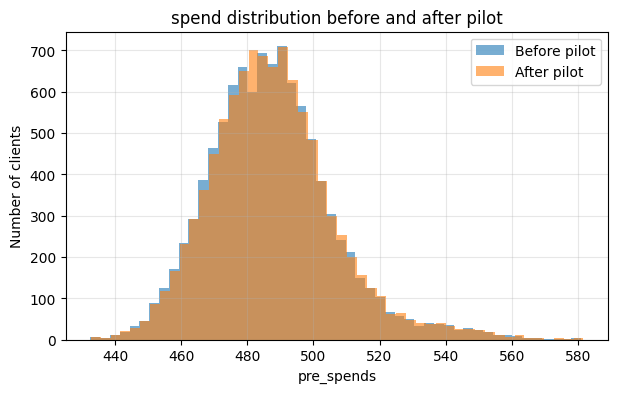

In [3]:
def describe_basic_info(df: pd.DataFrame):
    print("Basic statistics for numerical features:")
    display(df.describe().round(2))

def describe_cltv_effect(df: pd.DataFrame, group_col="treat"):
    result = (
        df.groupby(group_col)[["pre_spends", "post_spends"]]
        .mean()
        .rename(columns={"pre_spends": "mean_pre_spends", "post_spends": "mean_post_spends"})
    )
    result["delta_spend"] = result["post_spends"] - result["pre_spends"]
    print("Average spend before and after pilot:")
    print(result.round(2))
    result.plot(
        kind="bar",
        figsize=(6, 4),
        title="Average spend before and after pilot by groups",
        rot=0
    )
    plt.ylabel("Average spend")
    plt.grid(alpha=0.3)
    plt.show()

    return result

def plot_cltv_distribution(df: pd.DataFrame):
    plt.figure(figsize=(7, 4))
    plt.hist(df["pre_spends"], bins=50, alpha=0.6, label="Before pilot")
    plt.hist(df["post_spends"], bins=50, alpha=0.6, label="After pilot")
    plt.title("spend distribution before and after pilot")
    plt.xlabel("pre_spends")
    plt.ylabel("Number of clients")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def full_dataset_report(df: pd.DataFrame):
    describe_basic_info(df)
    plot_cltv_distribution(df)

full_dataset_report(df)

# Define the Dataset

In [4]:
data = Dataset(
    roles={
        "user_id": InfoRole(int),
        "treat": TreatmentRole(int),
        "post_spends": TargetRole(float),
        "gender": FeatureRole(str),
        "pre_spends": FeatureRole(float),
        "industry": FeatureRole(str),
        "age": FeatureRole(int),
    },
    data=df,
    default_role=InfoRole(),
)
data

,user_id,signup_month,treat,pre_spends,post_spends,age,gender,industry
0,0,11,1,467.0,467.356649,49,M,Logistics
1,1,4,1,459.0,459.311958,24,M,Logistics
2,2,7,1,483.0,483.00437,30,F,Finance
3,3,11,1,512.0,512.44115,23,F,Logistics
4,4,0,0,493.5,494.450061,40,F,E-commerce
...,...,...,...,...,...,...,...,...
9995,9995,0,0,488.5,489.006431,19,F,E-commerce
9996,9996,10,1,477.0,477.159314,28,M,Logistics
9997,9997,0,0,453.5,453.589968,22,M,Logistics
9998,9998,9,1,497.0,497.897464,61,M,Logistics


In [5]:
data.roles

{'user_id': Info(<class 'int'>),
 'treat': Treatment(<class 'int'>),
 'post_spends': Target(<class 'float'>),
 'gender': Feature(data_type=<class 'str'>),
 'pre_spends': Feature(data_type=<class 'float'>),
 'industry': Feature(data_type=<class 'str'>),
 'age': Feature(data_type=<class 'int'>),
 'signup_month': Info(<class 'int'>)}

# Basic Matching without parameters

Main matching steps (in HypEx):

1. **Dummy Encoder**
   Converts categorical features to numerical format 

2. **Distance matrix calculation (usually Mahalanobis)**
   
3. **Finding nearest pairs (via FAISS)**
   
4. **Quality check of twin matching**

5. **Effect estimation (ATT, ATC, ATE)**

In [6]:
data = data.fillna(method="bfill")
test = Matching()
result = test.execute(data)

/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())
/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())


In [7]:
result.summary

,Effect Size,Standard Error,P-value,CI Lower,CI Upper
ATT,-0.02,0.01,0.17,-0.04,0.01
ATC,-0.00,0.01,0.85,-0.02,0.02
ATE,-0.01,0.01,0.35,-0.03,0.01


### ATT — Average Treatment effect on the Treated

$
ATT = E[Y(1) - Y(0) \mid T=1]
$
 - shows **how the treatment affected those who actually received it**.

### ATC — Average Treatment effect on the Controls 

$
ATC = E[Y(1) - Y(0) \mid T=0]
$
 - shows **what would have happened to the control group if they had received the treatment**.

### ATE — Average Treatment Effect

$
ATE = E[Y(1) - Y(0)]
$
- the overall average effect in the population — a combination of ATT and ATC, weighted by group sizes.

In [8]:
result.indexes

,indexes_0
0,7060
1,3723
2,5548
3,9920
4,277
...,...
9995,9604
9996,6684
9997,3127
9998,713


In [9]:
result.full_data

,user_id,signup_month,treat,pre_spends,post_spends,age,gender,industry,DummyEncoder┴┴_gender_M,DummyEncoder┴┴_industry_Finance,...,post_spends_matched_0,age_matched_0,gender_matched_0,industry_matched_0,DummyEncoder┴┴_gender_M_matched_0,DummyEncoder┴┴_industry_Finance_matched_0,DummyEncoder┴┴_industry_Logistics_matched_0,FaissNearestNeighbors┴┴┴0_matched_0,Bias┴┴post_spends_bias_matched_0,Bias┴┴post_spends_matched_target_matched_0
0,0,11,1,467.0,467.356649,49.0,M,Logistics,1.0,0.0,...,467.460675,51.0,M,Logistics,1.0,0.0,1.0,6798,0.499893,468.313759
1,1,4,1,459.0,459.311958,24.0,M,Logistics,1.0,0.0,...,459.097536,25.0,M,Logistics,1.0,0.0,1.0,1,0.498959,459.311958
2,2,7,1,483.0,483.00437,30.0,F,Finance,0.0,1.0,...,483.021289,29.0,F,Finance,0.0,1.0,0.0,2,0.500827,483.00437
3,3,11,1,512.0,512.44115,23.0,F,Logistics,0.0,0.0,...,513.493629,25.0,F,Logistics,0.0,0.0,1.0,8996,0.499893,513.563249
4,4,0,0,493.5,494.450061,40.0,F,E-commerce,0.0,0.0,...,495.270195,40.0,F,E-commerce,0.0,0.0,0.0,4,-1.000936,494.450061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,0,0,488.5,489.006431,19.0,F,E-commerce,0.0,0.0,...,488.701154,20.0,F,E-commerce,0.0,0.0,0.0,9995,0.501108,489.006431
9996,9996,10,1,477.0,477.159314,28.0,M,Logistics,1.0,0.0,...,478.698168,27.0,M,Logistics,1.0,0.0,1.0,5292,-0.500827,477.821678
9997,9997,0,0,453.5,453.589968,22.0,M,Logistics,1.0,0.0,...,455.639721,20.0,M,Logistics,1.0,0.0,1.0,8114,-0.501108,455.428271
9998,9998,9,1,497.0,497.897464,61.0,M,Logistics,1.0,0.0,...,496.814127,61.0,M,Logistics,1.0,0.0,1.0,1672,0.0,496.544024


## Distances: `distance="mahalanobis"` or `"l2"`

### 🔸 Euclidean (L2)

This is the classic metric:
$ d(x_i, x_j) = \sqrt{\sum_k (x_{ik} - x_{jk})^2} $
Simply measures the "geometric" distance between points in feature space.

### 🔸 Mahalanobis distance

A more advanced metric:
$ d_M(x_i, x_j) = \sqrt{(x_i - x_j)^T \Sigma^{-1} (x_i - x_j)} $
where $\Sigma$ is the covariance matrix of features.
This metric accounts for the scale and correlation of features, making the comparison more accurate:

In [10]:
test = Matching(distance='l2')
result = test.execute(data)

/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())


In [11]:
result.summary

,Effect Size,Standard Error,P-value,CI Lower,CI Upper
ATT,-0.01,0.01,0.46,-0.04,0.02
ATC,0.01,0.01,0.44,-0.01,0.03
ATE,-0.00,0.01,0.93,-0.02,0.02


In [12]:
test = Matching(distance='mahalanobis')
result = test.execute(data)

/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())
/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())


In [13]:
result.summary

,Effect Size,Standard Error,P-value,CI Lower,CI Upper
ATT,-0.02,0.01,0.17,-0.04,0.01
ATC,-0.00,0.01,0.85,-0.02,0.02
ATE,-0.01,0.01,0.35,-0.03,0.01


# `group_match`: matching by groups

The parameter `group_match=True` forces HypEx to aggregate observations into groups (by a specified identifier), and then search for pairs between groups rather than individual objects.
This reduces variability at the individual level and allows for effect estimation at more aggregated levels.

In [14]:
data = Dataset(
    roles={
        "user_id": InfoRole(int),
        "treat": TreatmentRole(int),
        "post_spends": TargetRole(float),
        "gender": GroupingRole(str),
        "pre_spends": FeatureRole(float),
        "industry": FeatureRole(str),
        "age": FeatureRole(int),
    },
    data=df,
    default_role=InfoRole(),
)
data['gender'].unique()

{'gender': 0    M
 1    F
 dtype: object}

We can change **metric** and do estimation again.

In [15]:
test = Matching(group_match=True)
result = test.execute(data)

/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())
  0%|          | 0/2 [00:00<?, ?it/s]/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())
/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())
/Users/danilsamsutdinov/HypEx/hypex/extensions/bias.py:383: UserWarning: BiasExtension: 2313 of 4998 observations have no valid match. They will be excluded from the treatment e

In [16]:
result.summary

,F Effect Size,F Standard Error,F P-value,F CI Lower,F CI Upper,M Effect Size,M Standard Error,M P-value,M CI Lower,M CI Upper
ATC,0.00,0.02,0.83,-0.03,0.04,-0.02,0.02,0.27,-0.05,0.02
ATE,-0.02,0.02,0.34,-0.05,0.02,-0.02,0.02,0.15,-0.05,0.01
ATT,-0.03,0.02,0.10,-0.07,0.01,-0.03,0.02,0.19,-0.06,0.01


# `bias_estimation`: bias estimation and correction

When `bias_estimation=True`, HypEx:

1. **Estimates residual imbalance** across all features after matching (e.g., using standardized mean difference, t-tests, etc.);
2. **Corrects the final effect estimate** to reduce the impact of remaining bias.


In [17]:
data = Dataset(
    roles={
        "user_id": InfoRole(int),
        "treat": TreatmentRole(int),
        "post_spends": TargetRole(float),
        "gender": FeatureRole(str),
        "pre_spends": FeatureRole(float),
        "industry": FeatureRole(str),
        "age": FeatureRole(int),
    },
    data=df,
    default_role=InfoRole(),
)

In [18]:
test = Matching(bias_estimation=False)
result = test.execute(data)

/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())
/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())


In [19]:
result.summary

,Effect Size,Standard Error,P-value,CI Lower,CI Upper
ATT,0.79,0.07,0.00,0.65,0.93
ATC,0.04,0.11,0.71,-0.17,0.25
ATE,0.41,0.08,0.00,0.26,0.57


# `quality_tests`: matching quality checks

Main tests:

* `'ks-test'` — Kolmogorov–Smirnov test for comparing distributions;
* `'t-test'` — test for equality of means;
* `'chi2-test'` — test for independence of categorical features;

These tests help understand whether balance was achieved and how reliable the result can be considered.

In [20]:
test = Matching(quality_tests=['chi2-test', 'ks-test', 't-test'])
result = test.execute(data)

/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())
/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())


In [21]:
result.summary

,Effect Size,Standard Error,P-value,CI Lower,CI Upper
ATT,-0.02,0.01,0.17,-0.04,0.01
ATC,-0.00,0.01,0.85,-0.02,0.02
ATE,-0.01,0.01,0.35,-0.03,0.01


In [22]:
result.quality_results

,feature,group,TTest pass,TTest p-value,KSTest pass,KSTest p-value,Chi2Test pass,Chi2Test p-value
0,pre_spends,0,OK,0.894353,OK,0.999997,NaN,NaN
1,pre_spends,1,NOT OK,0.046893,NOT OK,0.000242,NaN,NaN
2,age,0,OK,0.959367,OK,1.000000,NaN,NaN
3,age,1,OK,0.837053,OK,0.963426,NaN,NaN
4,gender,0,NaN,NaN,NaN,NaN,NOT OK,0.0
5,gender,1,NaN,NaN,NaN,NaN,NOT OK,0.0
6,industry,0,NaN,NaN,NaN,NaN,NOT OK,0.0
7,industry,1,NaN,NaN,NaN,NaN,NOT OK,0.0


# `faiss_mode`: search acceleration

FAISS is a high-performance library for nearest neighbor search, developed by Meta AI.
HypEx uses it for finding pairs in large datasets.

Modes:

* `'base'` — exact but slow search;
* `'fast'` — approximate but fast (uses indexing);
* `'auto'` — HypEx automatically chooses the optimal option depending on data size.


In [23]:
test = Matching(faiss_mode="base")
result = test.execute(data)
result.summary

/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())
/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())


,Effect Size,Standard Error,P-value,CI Lower,CI Upper
ATT,-0.02,0.01,0.17,-0.04,0.01
ATC,-0.00,0.01,0.85,-0.02,0.02
ATE,-0.01,0.01,0.35,-0.03,0.01


Finally, we may search pairs in L2 distance. 

In [24]:
test = Matching(faiss_mode="fast")
result = test.execute(data)
result.summary

/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())
/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())
/Users/danilsamsutdinov/HypEx/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/Users/danilsamsutdinov/HypEx/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


,Effect Size,Standard Error,P-value,CI Lower,CI Upper
ATT,-0.01,0.01,0.24,-0.04,0.01
ATC,-0.00,0.01,0.80,-0.03,0.02
ATE,-0.01,0.01,0.39,-0.03,0.01


# `n_neighbors`: number of neighbors

Determines how many control objects will be matched for each object from the treatment group.

* `n_neighbors=1` — classic **one-to-one matching**;
* `n_neighbors>1` — **one-to-many matching**, when one treated object corresponds to multiple control objects.


In [25]:
test = Matching(n_neighbors=3)
result = test.execute(data)
result.summary

/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())
/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())
/Users/danilsamsutdinov/HypEx/hypex/comparators/abstract.py:258: UserWarning: baseline_field_data must have only one column when the comparison is done by matched_pairs. 3 passed. FaissNearestNeighbors┴┴┴0 will be used.
  warnings.warn(
/Users/danilsamsutdinov/HypEx/hypex/comparators/abstract.py:258: UserWarning: baseline_field_data must have only one column when the comparison is done by matched_pairs. 3 passed. FaissNearestNeighbors┴┴┴0 will be used.
  warnings.warn(
/U

,Effect Size,Standard Error,P-value,CI Lower,CI Upper
ATT,-0.01,0.01,0.08,-0.03,0.00
ATC,0.00,0.01,0.68,-0.01,0.02
ATE,-0.01,0.01,0.46,-0.02,0.01


In [26]:
result.indexes

,indexes_2,indexes_0,indexes_1
0,1407,7060,7061
1,4591,3723,4590
2,9708,5548,4216
3,7368,9920,9921
4,8146,277,2194
...,...,...,...
9995,1216,9604,1655
9996,2627,6684,5956
9997,1016,3127,576
9998,5642,713,6002


In [27]:
result.full_data

,user_id,signup_month,treat,pre_spends,post_spends,age,gender,industry,DummyEncoder┴┴_gender_M,DummyEncoder┴┴_industry_Finance,...,gender_matched_2,industry_matched_2,DummyEncoder┴┴_gender_M_matched_2,DummyEncoder┴┴_industry_Finance_matched_2,DummyEncoder┴┴_industry_Logistics_matched_2,FaissNearestNeighbors┴┴┴0_matched_2,FaissNearestNeighbors┴┴┴1_matched_2,FaissNearestNeighbors┴┴┴2_matched_2,Bias┴┴post_spends_bias_matched_2,Bias┴┴post_spends_matched_target_matched_2
0,0,11,1,467.0,467.356649,49.0,M,Logistics,1.0,0.0,...,M,Logistics,1.0,0.0,1.0,6798,0,5890,0.999973,468.710136
1,1,4,1,459.0,459.311958,24.0,M,Logistics,1.0,0.0,...,M,Logistics,1.0,0.0,1.0,1,1016,576,-2.333572,458.734958
2,2,7,1,483.0,483.00437,30.0,F,Finance,0.0,1.0,...,F,Finance,0.0,1.0,0.0,2,2228,5655,0.333174,484.947917
3,3,11,1,512.0,512.44115,23.0,F,Logistics,0.0,0.0,...,F,Logistics,0.0,0.0,1.0,8996,3,4387,0.166362,513.476253
4,4,0,0,493.5,494.450061,40.0,F,E-commerce,0.0,0.0,...,F,E-commerce,0.0,0.0,0.0,9436,4,6458,-0.166732,493.912183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,0,0,488.5,489.006431,19.0,F,E-commerce,0.0,0.0,...,F,E-commerce,0.0,0.0,0.0,9995,5944,3895,0.666246,490.766566
9996,9996,10,1,477.0,477.159314,28.0,M,Logistics,1.0,0.0,...,M,Logistics,1.0,0.0,1.0,5693,4587,9996,-0.499987,478.351661
9997,9997,0,0,453.5,453.589968,22.0,M,Logistics,1.0,0.0,...,M,Logistics,1.0,0.0,1.0,528,3723,26,-0.666473,456.7219
9998,9998,9,1,497.0,497.897464,61.0,M,Logistics,1.0,0.0,...,M,Logistics,1.0,0.0,1.0,9998,1672,4067,-0.833537,497.27938


# `weights`: feature weights

Not all features may be equally important for matching pairs.
The `weights` parameter allows you to explicitly set priorities for features.


In [28]:
test = Matching(weights={"gender": 0.2, "industry": 0.3, "age": 0.1, "signup_month": 0.1, "pre_spends": 0.3})
result = test.execute(data)
result.summary

/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())
/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())


,Effect Size,Standard Error,P-value,CI Lower,CI Upper
ATT,-0.02,0.01,0.20,-0.04,0.01
ATC,-0.00,0.01,0.89,-0.02,0.02
ATE,-0.01,0.01,0.39,-0.03,0.01


# `encode_categories`: encoding categorical features

If `encode_categories=True` (default), HypEx automatically converts categorical features to numerical form (one-hot encoding).
If False — the library expects that the user has already encoded them.
This step is necessary so that all features can participate in distance calculations.


In [29]:
test = Matching(encode_categories=False)
result = test.execute(data)
result.summary

/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())
/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1238: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())


,Effect Size,Standard Error,P-value,CI Lower,CI Upper
ATT,-0.01,0.01,0.40,-0.04,0.02
ATC,0.00,0.01,0.71,-0.02,0.03
ATE,-0.00,0.01,0.72,-0.03,0.02
